# Part 1 — Dataset Creation

> **⚠️ This notebook was run before the tutorial to build the dataset. You do not need to run it.**
> The pre-built dataset is available in the `dataset/` folder.

This notebook queries real astronomical data from the [ALeRCE broker](https://alerce.science/) and assembles two datasets:

| Dataset | Source | Classes | Objects per class |
|---------|--------|---------|------------------|
| **Image stamps** | ZTF / stamp classifier | AGN, SN, VS, Asteroid, Bogus | 100 |
| **Light curves** | ZTF / LC classifier | SNIa, SNIbc, SNII, SLSN | 100 |

These two datasets will feed the two transformer models we build in Parts 2 and 3.

---
## 1 — ALeRCE and the ZTF Alert Stream

[ALeRCE](https://alerce.science/) is a Chilean-led astronomical broker that processes the real-time alert stream from the **Zwicky Transient Facility (ZTF)**. ZTF scans the northern sky every few nights and generates an alert each time a brightness change is detected. ALeRCE ingests, classifies, and exposes these alerts through a public API.

Each alert carries two complementary data products:

- **Image stamps** — three 21×21 pixel cutouts: *science* (current observation), *reference* (archival baseline), and their *difference*.
- **Light curve** — the full time series of brightness measurements across ZTF bands (*g* = band 1, *r* = band 2).

ALeRCE runs two classifiers whose predictions we use as class labels:
1. **Stamp classifier** ([Carrasco-Davis et al. 2021](https://arxiv.org/abs/2008.03309)) — classifies from the *first alert only*: AGN, SN, VS, Asteroid, Bogus.
2. **Light curve classifier** ([Sánchez-Sáez et al. 2021](https://arxiv.org/abs/2008.03311)) — classifies from the *full light curve* into 15 sub-classes; we focus on the four transient ones: SNIa, SNIbc, SNII, SLSN.

We query only objects with classification probability > 0.8 to keep labels clean.

![ALeRCE taxonomy](figures/taxonomy.png)

---
## 2 — Setup

In [1]:
!pip install alerce scipy --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from alerce.core import Alerce
from utils import download_lc, passes_min_detections, interpolate_lc, EVAL_DATE, MIN_TIME, STEP

client = Alerce()

DATASET_DIR = Path("dataset")
DATASET_DIR.mkdir(exist_ok=True)

N_OBJECTS = 100
MIN_PROB  = 0.7

---
## 3 — Image Stamp Dataset

For each object we download the 21×21 px triplet (science, reference, difference) from its **first detection** and stack it into a tensor of shape **(3, 21, 21)** — the format the Vision Transformer will expect.

![Stamp examples](figures/class_samples.png)

In [3]:
STAMP_CLASSES = ["AGN", "SN", "VS"]
STAMP_SIZE    = 63  # expected cutout side length in pixels


def download_stamp(oid: str) -> np.ndarray | None:
    """Return first-detection stamp as float32 (3, 21, 21), or None on failure.

    Skips stamps whose cutout size differs from STAMP_SIZE (older ZTF alerts
    occasionally return different dimensions).
    """
    try:
        det = client.query_detections(oid, format="pandas").sort_values("mjd")
        candid = det.loc[det["has_stamp"]].iloc[0]["candid"]
        raw = client.get_stamps(oid, candid)
        planes = [raw[0].data, raw[1].data, raw[2].data]
        if any(p.shape != (STAMP_SIZE, STAMP_SIZE) for p in planes):
            return None
        return np.stack(planes, axis=0).astype(np.float32)
    except Exception as exc:
        print(f"    [SKIP] {oid}: {exc}")
        return None


stamps_list, stamp_labels, stamp_oids = [], [], []

for label_idx, cl in enumerate(STAMP_CLASSES):
    objects = client.query_objects(
        classifier="stamp_classifier", class_name=cl,
        probability=MIN_PROB, ranking=1,
        order_by="probability", order_mode="DESC",
        count=False, page_size=N_OBJECTS, format="pandas",
    ).set_index("oid")
    print(f"{cl}: {len(objects)} objects queried")
    for oid in objects.index:
        stamp = download_stamp(oid)
        if stamp is not None:
            stamps_list.append(stamp)
            stamp_labels.append(label_idx)
            stamp_oids.append(oid)

stamps_array = np.stack(stamps_list)    # (N, 3, 21, 21)
stamp_labels = np.array(stamp_labels)   # (N,)
print(f"\nStamps: {stamps_array.shape}")
print("Per class:", {cl: int((stamp_labels == i).sum()) for i, cl in enumerate(STAMP_CLASSES)})

AGN: 100 objects queried


SN: 100 objects queried
VS: 100 objects queried
    [SKIP] ZTF18aaxfcmb: Not a gzipped file (b'{"')
    [SKIP] ZTF18aagzkvt: Not a gzipped file (b'<h')
    [SKIP] ZTF22aahtyiv: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18acidohz: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abcgthj: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18absubim: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF17aadihgk: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abyplqa: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abuyhrm: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF26aaqzuvf: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unkno

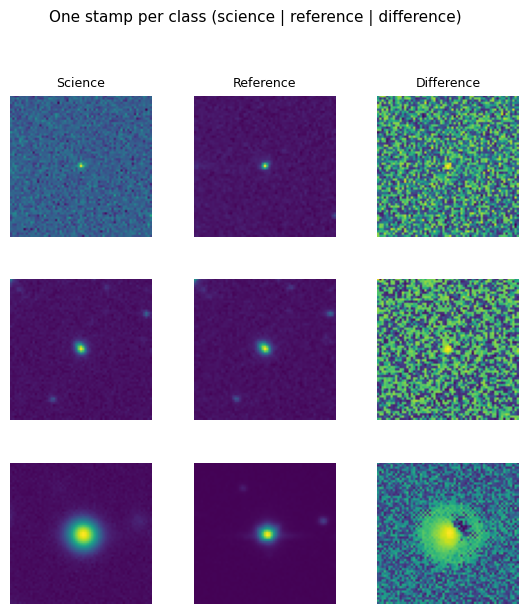

In [4]:
fig, axes = plt.subplots(len(STAMP_CLASSES), 3, figsize=(7, len(STAMP_CLASSES) * 2.2),
                         gridspec_kw={"wspace": 0.05, "hspace": 0.3})
for row, cl in enumerate(STAMP_CLASSES):
    idx = np.where(stamp_labels == row)[0][0]
    for col, title in enumerate(["Science", "Reference", "Difference"]):
        ax = axes[row, col]
        ax.imshow(np.arcsinh(stamps_array[idx, col]), cmap="viridis", origin="lower")
        ax.axis("off")
        if row == 0: ax.set_title(title, fontsize=9)
        if col == 0: ax.set_ylabel(cl, fontsize=9, rotation=0, labelpad=40, va="center")
fig.suptitle("One stamp per class (science | reference | difference)", fontsize=11, y=1.01)
plt.savefig(DATASET_DIR / "stamp_examples.png", bbox_inches="tight", dpi=120)
plt.show()

In [5]:
np.savez(DATASET_DIR / "stamps.npz",
    stamps=stamps_array,
    labels=stamp_labels,
    oids=np.array(stamp_oids),
    class_names=np.array(STAMP_CLASSES),
)
print("Saved:", DATASET_DIR / "stamps.npz")

Saved: dataset/stamps.npz


---
## 4 — Light Curve Dataset

### Preprocessing strategy

Raw ZTF light curves are **irregularly sampled**: observations happen when the telescope can observe and weather permits. To remove this complexity from the transformer, we interpolate onto a regular grid following [Pérez-Carrasco et al. 2023](https://iopscience.iop.org/article/10.3847/1538-3881/ace0c1):

- Time is expressed relative to each object's **first detection** (`dt = mjd − first_mjd`)
- **Non-detections** before the trigger are prepended to anchor the pre-explosion baseline
- Linear interpolation maps each band onto a **regular 3-day grid** from −30 to +150 days
- Unobserved steps are filled with 0 and flagged by a **binary mask**

The result is a fixed-length tensor of shape **(T=60, 2)** per object — 60 time steps × 2 bands — plus a mask of the same shape. Implementation is in `utils/lc_preprocessing.py`. We keep only objects with ≥10 detections per band.

In [11]:
LC_CLASSES       = ["SNIa", "SNIbc", "SNII", "SLSN"]
MIN_DET_PER_BAND = 10
label_map        = {cl: i for i, cl in enumerate(LC_CLASSES)}
MIN_PROB  = 0.6

lc_fluxes, lc_masks, lc_labels, lc_oids = [], [], [], []
times = None  # shared time axis, same for every object

for cl in LC_CLASSES:
    # Note: lc_classifier does not support probability/ranking as query filters.
    # We request more objects and filter by probability post-query.
    objects = client.query_objects(
        classifier="lc_classifier", class_name=cl,
        order_by="probability", order_mode="DESC",
        page_size=N_OBJECTS * 2, format="pandas",
    )
    objects = objects[objects["probability"] >= MIN_PROB].head(N_OBJECTS).set_index("oid")
    print(f"{cl}: {len(objects)} objects queried")

    for oid in objects.index:
        det, nondet = download_lc(oid, client)
        if det is None or not passes_min_detections(det, MIN_DET_PER_BAND):
            continue
        fluxes, masks, times = interpolate_lc(det, nondet)
        lc_fluxes.append(fluxes)
        lc_masks.append(masks)
        lc_labels.append(label_map[cl])
        lc_oids.append(oid)

lc_fluxes = np.stack(lc_fluxes)   # (N, T, 2)
lc_masks  = np.stack(lc_masks)    # (N, T, 2)
lc_labels = np.array(lc_labels)   # (N,)
print(f"\nLight curves: {lc_fluxes.shape}  — T={times.shape[0]} steps")
print("Per class:", {cl: int((lc_labels == i).sum()) for i, cl in enumerate(LC_CLASSES)})

SNIa: 100 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


SNIbc: 57 objects queried
SNII: 98 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504

SLSN: 100 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo



Light curves: (310, 60, 2)  — T=60 steps
Per class: {'SNIa': 91, 'SNIbc': 29, 'SNII': 98, 'SLSN': 92}


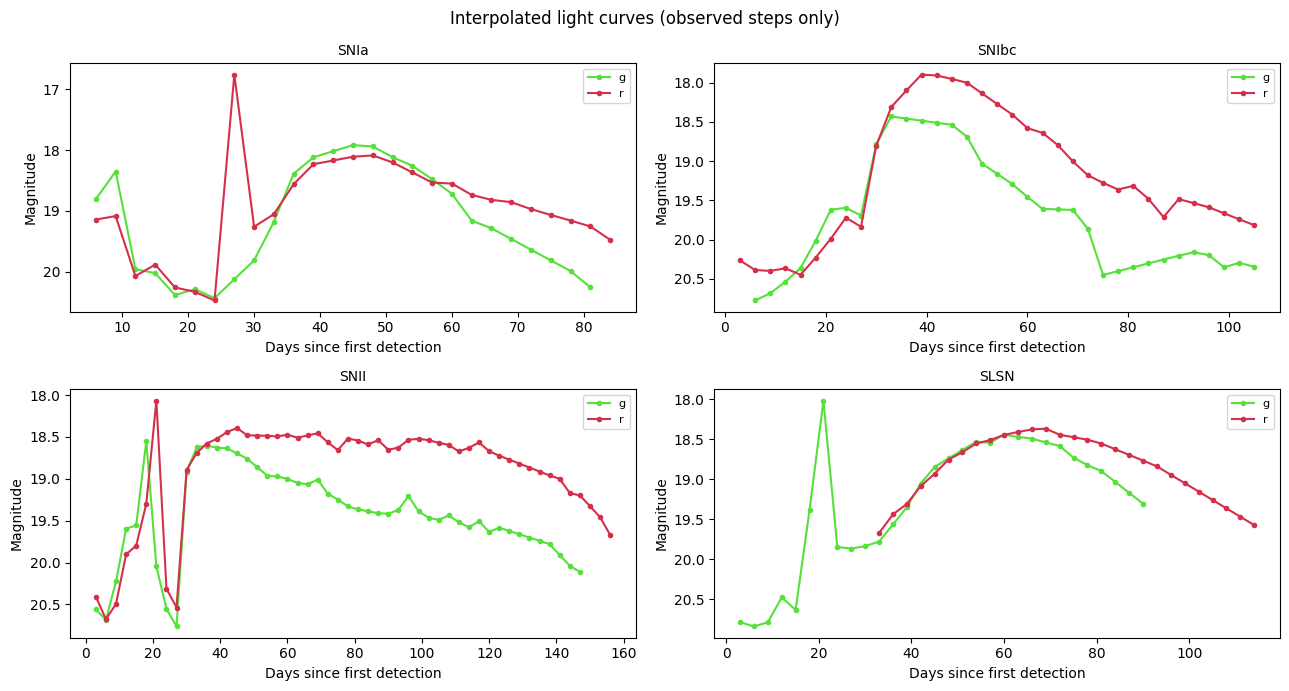

In [12]:
COLORS      = {0: "#56E03A", 1: "#D42F4B"}
BAND_LABELS = {0: "g", 1: "r"}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (cl, label_idx) in zip(axes.flatten(), label_map.items()):
    idx = np.where(lc_labels == label_idx)[0][0]
    for b in range(2):
        observed = lc_masks[idx, :, b] == 1
        ax.plot(times[observed], lc_fluxes[idx, observed, b], "o-",
                ms=3, color=COLORS[b], label=BAND_LABELS[b])
    ax.invert_yaxis()
    ax.set_title(cl, fontsize=10)
    ax.set_xlabel("Days since first detection")
    ax.set_ylabel("Magnitude")
    ax.legend(fontsize=8)
fig.suptitle("Interpolated light curves (observed steps only)", fontsize=12)
plt.tight_layout()
plt.savefig(DATASET_DIR / "lc_examples.png", dpi=120)
plt.show()

In [13]:
np.savez(DATASET_DIR / "lightcurves.npz",
    fluxes=lc_fluxes,
    masks=lc_masks,
    labels=lc_labels,
    oids=np.array(lc_oids),
    times=times,
    class_names=np.array(LC_CLASSES),
)
print("Saved:", DATASET_DIR / "lightcurves.npz")

Saved: dataset/lightcurves.npz


---
## 5 — Dataset Summary

In [14]:
stamps = np.load(DATASET_DIR / "stamps.npz",      allow_pickle=True)
lcs    = np.load(DATASET_DIR / "lightcurves.npz", allow_pickle=True)

print("=== Stamp dataset ===")
print(f"  shape   : {stamps['stamps'].shape}   # (N, channels, H, W)")
print(f"  classes : {list(stamps['class_names'])}")
print(f"  counts  : { {cl: int((stamps['labels']==i).sum()) for i, cl in enumerate(stamps['class_names'])} }")

print()
print("=== Light curve dataset ===")
print(f"  shape   : {lcs['fluxes'].shape}   # (N, T, bands)")
print(f"  window  : {MIN_TIME} to +{EVAL_DATE} days, step={STEP} days → T={lcs['times'].shape[0]}")
print(f"  classes : {list(lcs['class_names'])}")
print(f"  counts  : { {cl: int((lcs['labels']==i).sum()) for i, cl in enumerate(lcs['class_names'])} }")

=== Stamp dataset ===
  shape   : (286, 3, 63, 63)   # (N, channels, H, W)
  classes : ['AGN', 'SN', 'VS']
  counts  : {'AGN': 100, 'SN': 99, 'VS': 87}

=== Light curve dataset ===
  shape   : (310, 60, 2)   # (N, T, bands)
  window  : -30 to +150 days, step=3 days → T=60
  classes : ['SNIa', 'SNIbc', 'SNII', 'SLSN']
  counts  : {'SNIa': 91, 'SNIbc': 29, 'SNII': 98, 'SLSN': 92}


---

**Next →** Part 2 — Transformers